# TPC-H Q14 (Join → Update → Join)

Phase breakdown: `join1_build + join1_probe + update + join2_build + join2_probe`

- **SNAP**: every join = build + probe  (join2_build > 0)
- **MVHT**: first join = build + probe, second join = probe only  (join2_build ≈ 0)

Data prep generates a **pre-filtered LINEITEM** file (shipdate 1-month window) so the Rust binary reads only probe-relevant rows.

In [154]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'seaborn', 'matplotlib'])
print('done')

done



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [155]:
from pathlib import Path
import subprocess, os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style='whitegrid')

ROOT = Path('../../').resolve()
SIGMOD = (ROOT / 'benches' / 'sigmod').resolve()
DATA_DIR = SIGMOD / 'tpch_data'
DBGEN_DIR = SIGMOD / 'dbgen'
GEN_UPDATES = SIGMOD / 'generate_updates.py'
BIN = ROOT / 'target' / 'release' / 'tpch_q14_join_update_join'

# ===== CONFIG =====
PART_SF      = 1.0       # PART scale factor (SF=1 → 200K rows)
LINEITEM_SF  = 1.0       # LINEITEM scale factor (SF=1 → ~6M rows raw, ~100K after filter)
SHIPDATE_FROM = '1995-09-01'  # Q14 default date filter
SHIPDATE_TO   = '1995-10-01'  # 1-month window
UPDATE_PCTS  = [0.2, 0.4, 0.6, 0.8, 1.0]
BUCKET_NUM   = 4096
WARMUP       = 1          # warmup iterations (discarded)
REPEAT       = 10          # measured iterations
TRIM         = 2          # drop top/bottom N by total time → trimmed mean
SERIES       = [('heap', 'nr'), ('par', 'wr'), ('naive', 'nr')]
DISTS        = ['uniform', 'zipf0.99']
# ==================

OUT_CSV = DATA_DIR / f'q14_juj_part_sf{PART_SF}_li_sf{LINEITEM_SF}.csv'
print('ROOT:', ROOT)
print('CSV :', OUT_CSV)

ROOT: /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree
CSV : /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/sigmod/tpch_data/q14_juj_part_sf1.0_li_sf1.0.csv


In [156]:
# ── Build Rust binary ──
print('Building tpch_q14_join_update_join...')
result = subprocess.run(
    ['cargo', 'build', '--release', '--bin', 'tpch_q14_join_update_join'],
    cwd=ROOT, capture_output=True, text=True,
)
if result.returncode != 0:
    print('STDERR:', result.stderr)
    raise RuntimeError('cargo build failed')
print('Build OK')

Building tpch_q14_join_update_join...
Build OK


In [157]:
# ── Generate tables with dbgen ──
DATA_DIR.mkdir(parents=True, exist_ok=True)

def generate_table(sf, table_flag, out_name):
    out_path = DATA_DIR / out_name
    if out_path.exists():
        print(f'  {out_name} exists, skip')
        return out_path
    print(f'  Generating {out_name} (SF={sf}) ...')
    subprocess.run(
        ['./dbgen', '-s', str(sf), '-T', table_flag, '-f'],
        cwd=DBGEN_DIR, check=True, capture_output=True,
    )
    tbl_name = 'part.tbl' if table_flag == 'P' else 'lineitem.tbl'
    (DBGEN_DIR / tbl_name).rename(out_path)
    print(f'  → {out_path.name} ({out_path.stat().st_size / 1e6:.1f} MB)')
    return out_path

part_file = generate_table(PART_SF, 'P', f'part_sf{PART_SF}.tbl')
lineitem_raw = generate_table(LINEITEM_SF, 'L', f'lineitem_sf{LINEITEM_SF}.tbl')

# ── Filter LINEITEM by shipdate → slim probe file ──
# Output: L_PARTKEY|L_EXTENDEDPRICE|L_DISCOUNT  (3 columns only)
probe_file = DATA_DIR / f'lineitem_probe_sf{LINEITEM_SF}_{SHIPDATE_FROM}_{SHIPDATE_TO}.tbl'

if probe_file.exists():
    print(f'  {probe_file.name} exists, skip')
else:
    print(f'  Filtering LINEITEM [{SHIPDATE_FROM}, {SHIPDATE_TO}) ...')
    count = 0
    with open(lineitem_raw) as fin, open(probe_file, 'w') as fout:
        for line in fin:
            fields = line.rstrip('\n').split('|')
            if len(fields) < 11:
                continue
            # L_SHIPDATE = fields[10]
            shipdate = fields[10]
            if shipdate >= SHIPDATE_FROM and shipdate < SHIPDATE_TO:
                # write only L_PARTKEY, L_EXTENDEDPRICE, L_DISCOUNT
                fout.write(f'{fields[1]}|{fields[5]}|{fields[6]}\n')
                count += 1
    print(f'  → {probe_file.name}: {count:,} rows')

# Summary
part_rows = sum(1 for _ in open(part_file))
probe_rows = sum(1 for _ in open(probe_file))
print(f'\nPART: {part_rows:,} rows (build side)  |  LINEITEM filtered: {probe_rows:,} rows (probe side)')

  part_sf1.0.tbl exists, skip
  lineitem_sf1.0.tbl exists, skip
  lineitem_probe_sf1.0_1995-09-01_1995-10-01.tbl exists, skip

PART: 200,000 rows (build side)  |  LINEITEM filtered: 75,983 rows (probe side)


In [158]:
# ── Generate update files ──
def ensure_updates(pct, dist):
    pct_label = f'{pct:g}'
    fname = f'part_updates_sf{PART_SF}_{pct_label}pct_{dist}.tbl'
    fpath = DATA_DIR / fname
    if fpath.exists():
        return fpath
    cmd = [
        sys.executable, str(GEN_UPDATES),
        str(part_file), str(pct), str(PART_SF),
        '--output-dir', str(DATA_DIR),
    ]
    if 'zipf' in dist:
        theta = dist.replace('zipf', '')
        cmd += ['--zipf', theta]
    subprocess.run(cmd, check=True, capture_output=True)
    return fpath

for pct in UPDATE_PCTS:
    for dist in DISTS:
        p = ensure_updates(pct, dist)
        print(f'  {p.name}')
print('Updates ready')

  part_updates_sf1.0_0.2pct_uniform.tbl
  part_updates_sf1.0_0.2pct_zipf0.99.tbl
  part_updates_sf1.0_0.4pct_uniform.tbl
  part_updates_sf1.0_0.4pct_zipf0.99.tbl
  part_updates_sf1.0_0.6pct_uniform.tbl
  part_updates_sf1.0_0.6pct_zipf0.99.tbl
  part_updates_sf1.0_0.8pct_uniform.tbl
  part_updates_sf1.0_0.8pct_zipf0.99.tbl
  part_updates_sf1.0_1pct_uniform.tbl
  part_updates_sf1.0_1pct_zipf0.99.tbl
Updates ready


In [159]:
# ── Run benchmark sweep ──
if OUT_CSV.exists():
    OUT_CSV.unlink()
    print('Removed old CSV')

total_runs = len(UPDATE_PCTS) * len(DISTS) * len(SERIES)
run_i = 0

for pct in UPDATE_PCTS:
    pct_label = f'{pct:g}'
    for dist in DISTS:
        updates_file = ensure_updates(pct, dist)
        for (ttype, rmode) in SERIES:
            run_i += 1
            print(f'[{run_i}/{total_runs}] pct={pct_label} dist={dist} table={ttype} repair={rmode}')
            cmd = [
                str(BIN),
                '--part-file', str(part_file),
                '--lineitem-file', str(probe_file),
                '--updates-file', str(updates_file),
                '--table-type', ttype,
                '--repair-mode', rmode,
                '--bucket-num', str(BUCKET_NUM),
                '--warmup', str(WARMUP),
                '--repeat', str(REPEAT),
                '--trim', str(TRIM),
                '--update-pct', pct_label,
                '--distribution', dist,
                '--output-csv', str(OUT_CSV),
            ]
            r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
            if r.returncode != 0:
                print('  FAILED:', r.stderr[:300])
            else:
                for line in r.stdout.strip().split('\n'):
                    if 'total_ms' in line or 'trimmed' in line:
                        print(f'  {line.strip()}')

print(f'\nDone. Results → {OUT_CSV}')

Removed old CSV
[1/30] pct=0.2 dist=uniform table=heap repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_build_ms=172.136153, join1_probe_ms=36.947236, update_ms=0.133861, join2_build_ms=0.000000, join2_probe_ms=37.909583, total_ms=247.126833
[2/30] pct=0.2 dist=uniform table=par repair=wr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_build_ms=167.500486, join1_probe_ms=36.757715, update_ms=9.345285, join2_build_ms=0.000000, join2_probe_ms=52.254653, total_ms=265.858139
[3/30] pct=0.2 dist=uniform table=naive repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_build_ms=166.573299, join1_probe_ms=35.293521, update_ms=0.000007, join2_build_ms=185.375424, join2_probe_ms=39.332326, total_ms=426.574577
[4/30] pct=0.2 dist=zipf0.99 table=heap repair=nr
  trimmed mean: 10 runs total, dropped 2 lowest + 2 highest, averaging 6 runs
  join1_build_ms=149.945458, join1_

In [160]:
# ── Load & label results ──
df = pd.read_csv(OUT_CSV)

num_cols = [
    'update_pct',
    'join1_build_ms', 'join1_probe_ms',
    'update_ms',
    'join2_build_ms', 'join2_probe_ms',
    'total_join_update_join_ms',
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

table_map = {'Heap': 'MONO', 'Chain': 'DUAL', 'Par': 'EPOCH', 'Rust': 'RUST', 'Naive': 'SNAP'}
repair_map = {'Nr': 'NR', 'Rr': 'RR', 'Wr': 'WR'}
df['table_label'] = df['table_type'].map(table_map).fillna(df['table_type'])
df['repair_label'] = df['repair_mode'].map(repair_map).fillna(df['repair_mode'])
df['series'] = df['table_label'] + '-' + df['repair_label']
df.loc[df['table_label'] == 'SNAP', 'series'] = 'SNAP'

target_series = ['EPOCH-WR', 'MONO-NR', 'SNAP']
df = df[df['series'].isin(target_series)].copy()
df = df.sort_values(['distribution', 'update_pct', 'series']).reset_index(drop=True)
df.head(10)

,table_type,repair_mode,update_pct,distribution,part_rows,lineitem_rows,update_ops,join1_build_ms,join1_probe_ms,update_ms,join2_build_ms,join2_probe_ms,total_join_update_join_ms,join1_matched,join2_matched,join1_q14_ratio,join2_q14_ratio,table_label,repair_label,series
0,Par,Wr,0.2,uniform,200000,75983,400,167.500486,36.757715,9.345285,0.000000,52.254653,265.858139,75983,75983,16.380779,16.377525,EPOCH,WR,EPOCH-WR
1,Heap,Nr,0.2,uniform,200000,75983,400,172.136153,36.947236,0.133861,0.000000,37.909583,247.126833,75983,75983,16.380779,16.377525,MONO,NR,MONO-NR
2,Naive,Nr,0.2,uniform,200000,75983,400,166.573299,35.293521,0.000007,185.375424,39.332326,426.574577,75983,75983,16.380779,16.377525,SNAP,NR,SNAP
3,Par,Wr,0.4,uniform,200000,75983,800,154.983778,35.480674,7.845368,0.000000,45.592403,243.902222,75983,75983,16.380779,16.367966,EPOCH,WR,EPOCH-WR
4,Heap,Nr,0.4,uniform,200000,75983,800,141.964396,34.841118,0.250854,0.000000,33.655556,210.711923,75983,75983,16.380779,16.367966,MONO,NR,MONO-NR
5,Naive,Nr,0.4,uniform,200000,75983,800,164.669959,35.715007,0.000028,181.551924,37.698722,419.635639,75983,75983,16.380779,16.367966,SNAP,NR,SNAP
6,Par,Wr,0.6,uniform,200000,75983,1200,159.470937,38.749319,12.017875,0.000000,49.733361,259.971493,75983,75983,16.380779,16.403160,EPOCH,WR,EPOCH-WR
7,Heap,Nr,0.6,uniform,200000,75983,1200,147.293319,34.880688,0.361715,0.000000,33.938403,216.474125,75983,75983,16.380779,16.403160,MONO,NR,MONO-NR
8,Naive,Nr,0.6,uniform,200000,75983,1200,173.435597,36.995917,0.000041,193.438062,36.843187,440.712805,75983,75983,16.380779,16.403160,SNAP,NR,SNAP
9,Par,Wr,0.8,uniform,200000,75983,1600,156.508403,36.358979,8.938146,0.000000,45.774729,247.580257,75983,75983,16.380779,16.391863,EPOCH,WR,EPOCH-WR


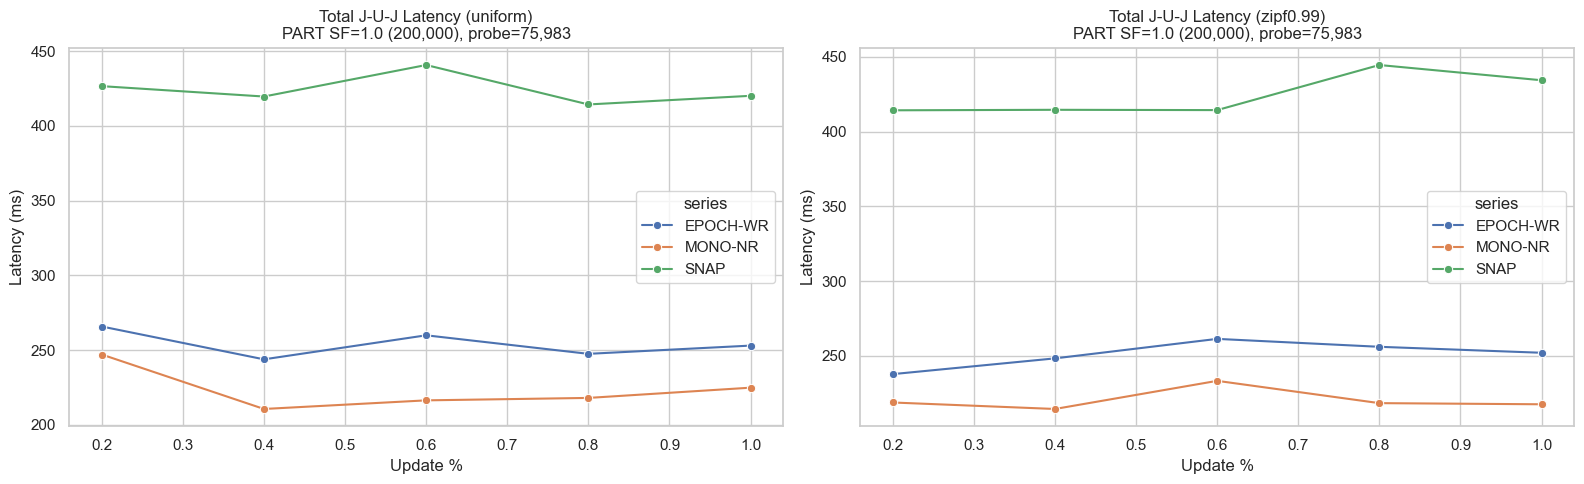

In [161]:
# ── Total J-U-J latency vs update% ──
dists = sorted(df['distribution'].dropna().unique())
fig, axes = plt.subplots(1, len(dists), figsize=(8 * len(dists), 5), squeeze=False)

for i, dist in enumerate(dists):
    ax = axes[0, i]
    sub = df[df['distribution'] == dist]
    sns.lineplot(data=sub, x='update_pct', y='total_join_update_join_ms',
                 hue='series', hue_order=target_series, marker='o', ax=ax)
    ax.set_title(f'Total J-U-J Latency ({dist})\nPART SF={PART_SF} ({part_rows:,}), probe={probe_rows:,}')
    ax.set_xlabel('Update %')
    ax.set_ylabel('Latency (ms)')

plt.tight_layout()
plt.show()

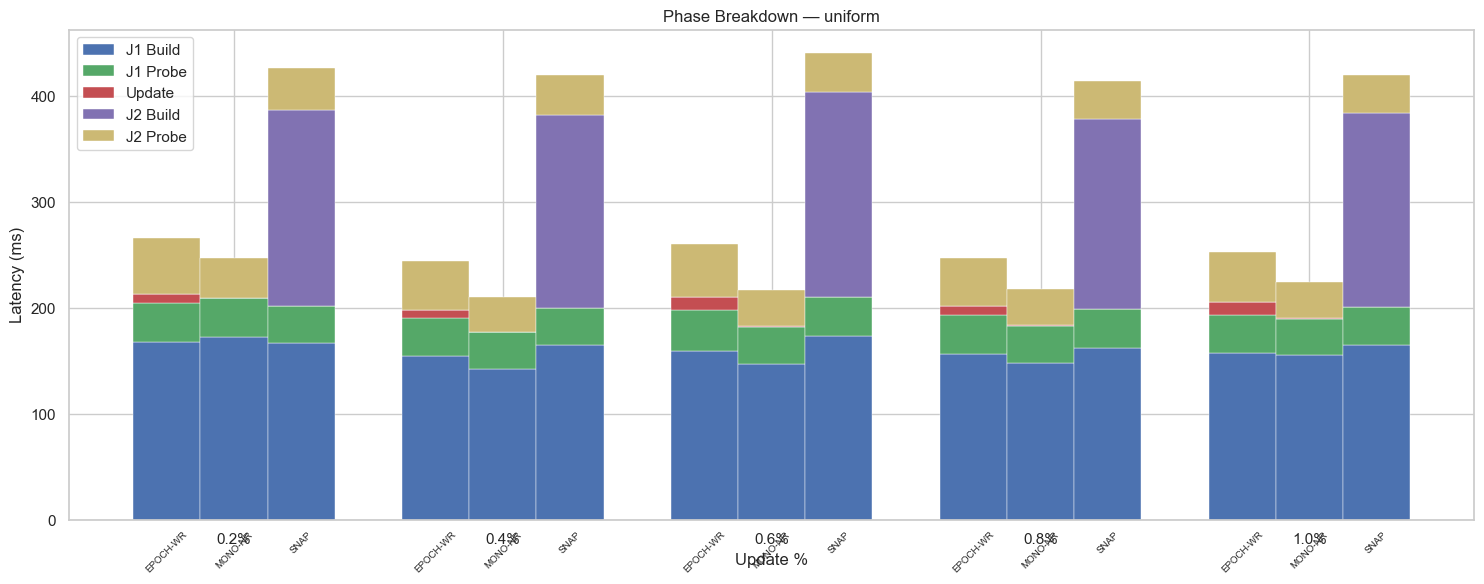

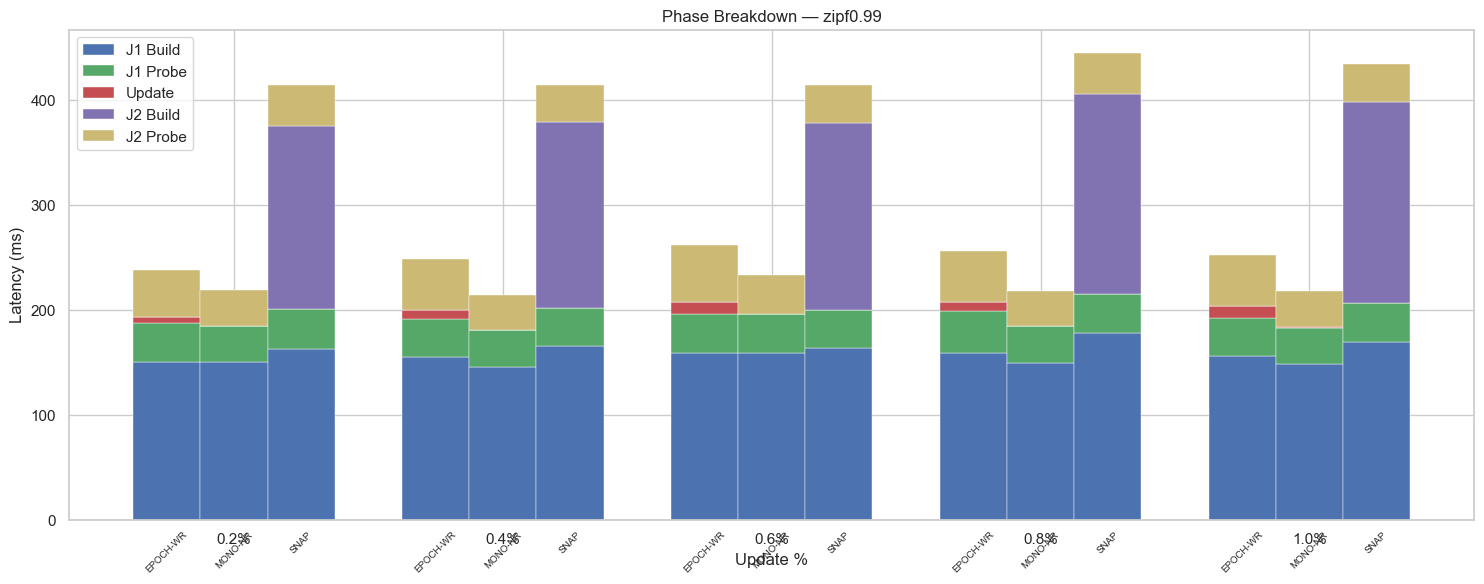

In [162]:
# ── Stacked bar: 5-phase breakdown ──
phases = ['join1_build_ms', 'join1_probe_ms', 'update_ms', 'join2_build_ms', 'join2_probe_ms']
phase_labels = ['J1 Build', 'J1 Probe', 'Update', 'J2 Build', 'J2 Probe']
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974']

for dist in dists:
    sub = df[df['distribution'] == dist].copy()
    agg = sub.groupby(['update_pct', 'series'], as_index=False)[phases].mean()

    series_list = [s for s in target_series if s in agg['series'].values]
    pcts = sorted(agg['update_pct'].unique())

    n_series = len(series_list)
    n_pcts = len(pcts)
    bar_w = 0.25
    x = np.arange(n_pcts)

    fig, ax = plt.subplots(figsize=(max(10, 3 * n_pcts), 6))

    for si, s in enumerate(series_list):
        sdf = agg[agg['series'] == s].set_index('update_pct').reindex(pcts)
        bottoms = np.zeros(n_pcts)
        for pi, (phase, lbl) in enumerate(zip(phases, phase_labels)):
            vals = sdf[phase].fillna(0).values
            label = lbl if si == 0 else None
            ax.bar(x + si * bar_w, vals, bar_w, bottom=bottoms,
                   color=colors[pi], label=label, edgecolor='white', linewidth=0.3)
            bottoms += vals

    ax.set_xticks(x + bar_w * (n_series - 1) / 2)
    ax.set_xticklabels([f'{p}%' for p in pcts])
    ax.set_xlabel('Update %')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(f'Phase Breakdown — {dist}')

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(phases)], phase_labels, loc='upper left')

    for si, s in enumerate(series_list):
        for xi in range(n_pcts):
            ax.text(x[xi] + si * bar_w, -0.02 * ax.get_ylim()[1], s,
                    ha='center', va='top', fontsize=7, rotation=45)

    plt.tight_layout()
    plt.show()

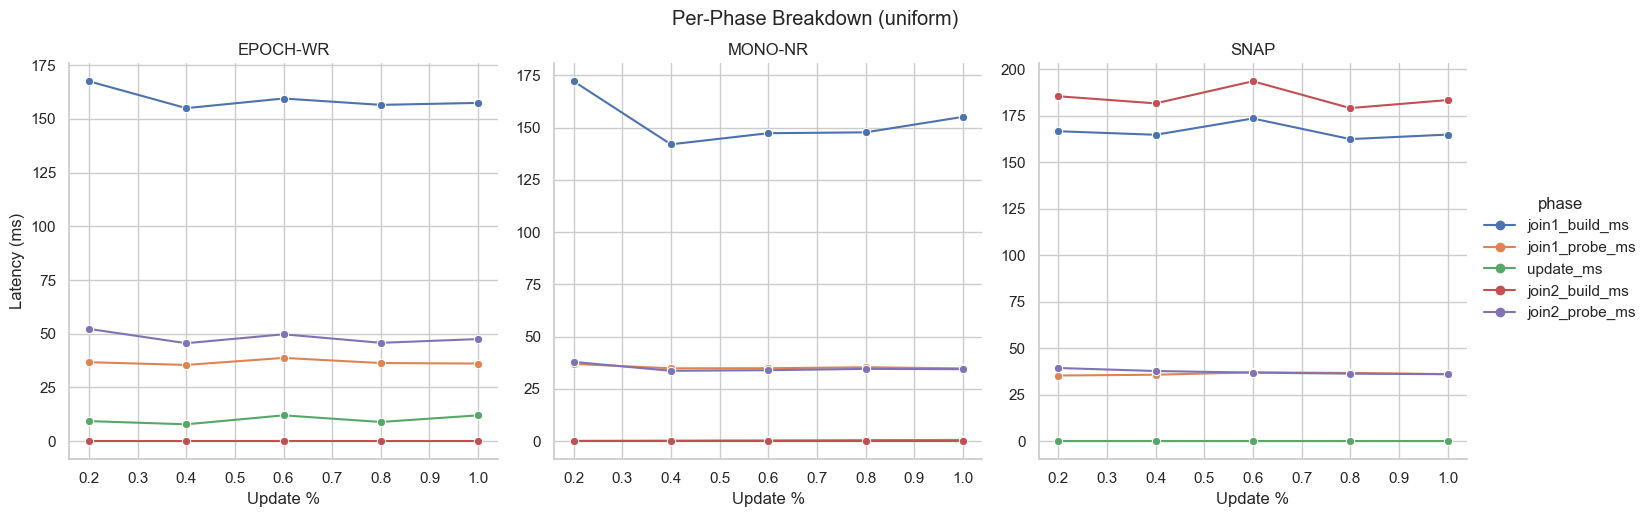

In [163]:
# ── Line plot: per-phase comparison ──
DIST = 'uniform'
sub = df[df['distribution'] == DIST].copy()
agg = sub.groupby(['update_pct', 'series'], as_index=False)[phases].mean()
melt = agg.melt(id_vars=['update_pct', 'series'], var_name='phase', value_name='ms')

g = sns.relplot(
    data=melt, x='update_pct', y='ms',
    hue='phase', col='series', col_order=target_series,
    col_wrap=3, kind='line', marker='o',
    facet_kws={'sharey': False},
)
g.set_titles('{col_name}')
g.set_axis_labels('Update %', 'Latency (ms)')
g.fig.suptitle(f'Per-Phase Breakdown ({DIST})', y=1.03)
plt.show()